# Wczytywanie danych z pliku JSON

**JSON** (*JavaScript Object Notation*) to popularny format do wymiany danych, szczególnie w API.

**Dlaczego JSON?**
- Format tekstowy, czytelny dla człowieka
- Standardowy format zwracany przez API
- Wspiera struktury hierarchiczne (zagnieżdżone obiekty)
- Natywnie obsługiwany przez JavaScript i większość języków

**Format:**
```json
[
  {
    "nazwa": "Laptop Dell XPS",
    "kategoria": "Elektronika",
    "cena": 4500.00,
    "ilosc": 12
  },
  ...
]
```

Tablica obiektów, gdzie każdy obiekt reprezentuje jeden rekord.

## 1. Import biblioteki

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Wczytanie danych z pliku JSON

Używamy `pd.read_json()` - funkcji do wczytywania danych JSON w Pandas.

**Podstawowe parametry:**
- `path_or_buf` - ścieżka do pliku lub string JSON
- `orient` - orientacja danych (np. `'records'` dla tablicy obiektów)
- `encoding` - kodowanie (np. `'utf-8'`)

In [3]:
# Wczytaj dane
df = pd.read_json("data/produkty.json")

# Wyświetl pierwsze 5 wierszy
print("Pierwsze 5 wierszy:")
print(df.head())

print("\nInformacje o danych:")
print(df.info())

Pierwsze 5 wierszy:
                    nazwa    kategoria     cena  ilosc
0         Laptop Dell XPS  Elektronika  4500.00     12
1           Mysz Logitech  Elektronika    89.99     45
2  Klawiatura mechaniczna  Elektronika   350.00     23
3      Biurko Ikea Bekant        Meble   890.00      8
4    Krzesło ergonomiczne        Meble  1200.00     15

Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   nazwa      15 non-null     str    
 1   kategoria  15 non-null     str    
 2   cena       15 non-null     float64
 3   ilosc      15 non-null     int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 612.0 bytes
None


## 3. Podstawowa eksploracja danych

In [4]:
# Statystyki opisowe
print("Statystyki opisowe:")
print(df.describe())

# Unikalne kategorie
print("\nKategorie produktów:")
print(df['kategoria'].unique())

Statystyki opisowe:
              cena      ilosc
count    15.000000  15.000000
mean    666.632000  30.933333
std    1140.364838  22.358976
min      35.000000   8.000000
25%      94.495000  16.500000
50%     179.990000  23.000000
75%     744.500000  38.000000
max    4500.000000  89.000000

Kategorie produktów:
<StringArray>
['Elektronika', 'Meble', 'Oświetlenie', 'Akcesoria']
Length: 4, dtype: str


## 4. Wizualizacja - Top 5 najdroższych produktów

Utworzymy prosty wykres słupkowy pokazujący 5 najdroższych produktów.

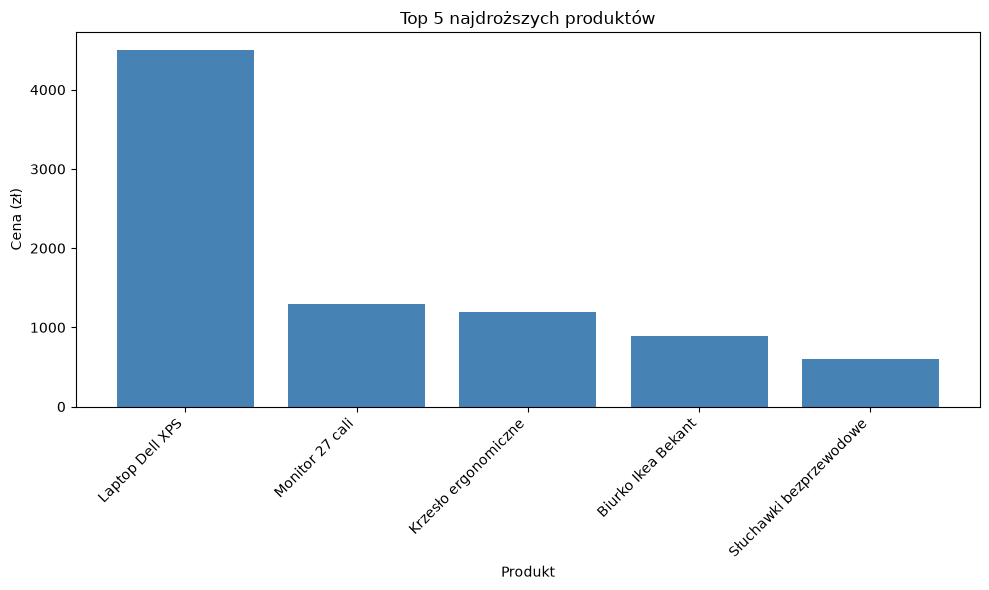

In [5]:
# Sortuj po cenie i weź top 5
top5 = df.nlargest(5, 'cena')

# Utwórz wykres
plt.figure(figsize=(10, 6))
plt.bar(top5['nazwa'], top5['cena'], color='steelblue')
plt.xlabel('Produkt')
plt.ylabel('Cena (zł)')
plt.title('Top 5 najdroższych produktów')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Podsumowanie

**Co zrobiliśmy:**
1. ✅ Wczytaliśmy dane z pliku JSON używając `pd.read_json()`
2. ✅ Zbadaliśmy strukturę danych (`head()`, `info()`, `describe()`)
3. ✅ Wizualizowaliśmy top 5 produktów na wykresie słupkowym

**Kluczowe funkcje:**
- `pd.read_json()` - wczytanie pliku JSON
- `df.head()` - pierwsze wiersze
- `df.nlargest()` - sortowanie i wybór największych wartości
- `plt.bar()` - wykres słupkowy

**JSON vs CSV:**
- JSON lepiej obsługuje dane hierarchiczne (zagnieżdżone struktury)
- CSV jest prostsze i szybsze dla danych tabelarycznych
- JSON jest standardem w komunikacji z API